In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r'D:\Python\project\data-science\data\raw\bsb_bank_statement.csv')

In [2]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

(4571, 9)
['Дата операции', 'Дата транзакции', '4 последние цифры номера карточки', 'Описание операции', 'Место проведения транзакции', 'Валюта транзакции', 'Сумма транзакции', 'Сумма в валюте карт-счета', 'Остаток карт-счета']
  Дата операции Дата транзакции  4 последние цифры номера карточки  \
0    2023-05-12      2023-05-12                             4995.0   
1    2023-05-29      2023-05-28                             4995.0   
2    2023-05-29      2023-05-28                             4995.0   
3    2023-05-29      2023-05-28                             4995.0   
4    2023-05-29      2023-05-28                             8176.0   

                                   Описание операции  \
0  Online открытие текущего счета с последующим в...   
1  Оплата товаров и услуг в устройствах других ба...   
2  Оплата товаров и услуг в устройствах других ба...   
3         Оплата товаров и услуг в устройствах Банка   
4                              Пополнение счета Ерип   

   Место прове

In [3]:
# Переименуем колонки для удобства (короткие английские названия)
df.columns = [
    'operation_date', 'transaction_date', 'card_last4',
    'description', 'place', 'currency',
    'amount_original', 'amount', 'balance'
]

# Преобразуем даты
df['operation_date'] = pd.to_datetime(df['operation_date'])
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Смотрим пропуски
print(df.isnull().sum())

# Основные типы операций
print(df['description'].value_counts().head(10))

operation_date       0
transaction_date     0
card_last4          84
description          0
place               87
currency             0
amount_original      0
amount               0
balance              0
dtype: int64
description
Оплата товаров и услуг в устройствах других банков                 4049
Пополнение счета Ерип                                               178
Оплата товаров и услуг в устройствах Банка                          105
Капитализация (%% тек.периода ко вкладу)                             37
Начисление Money- back (Программа money-back "Стандарт")             37
Оплата товаров и услуг                                               26
Оплата товаров и услуг в устройствах                                 25
Оплата товаров и услуг в устройствах других                          25
Списание P2P в устройствах других банков                             20
Плата за перевод с карт-счета на карт-счет (в устр. др. банков)      16
Name: count, dtype: int64


In [4]:
# Создаём признак: это расход или пополнение
df['is_expense'] = df['description'].str.contains('Оплата|Списание|Плата|Снятие', case=False, na=False)
df['is_income'] = df['description'].str.contains('Пополнение|Начисление|Возвращенная|Капитализация', case=False, na=False)

# Топ мест по сумме расходов
expenses = df[df['is_expense']]
print("Топ-15 мест по сумме расходов:")
print(expenses.groupby('place')['amount'].sum().sort_values(ascending=False).head(15))

Топ-15 мест по сумме расходов:
place
INTERNET-BANKING BSB         19635.95
UNIVERSAM                     4429.33
PERSON TO PERSON MP BSB       4228.00
SHOP SOSEDI                   3400.68
SHOP "SANTA-270" BAPB         3211.23
SHOP "SOSEDI"                 3183.30
SHOP "EUROOPT PRIME"          2733.99
WWW.WILDBERRIES.BY            1840.09
SHOP "EVROOPT"                1279.67
I.-SHOP "WILDBERRIES.BY"      1088.89
SHOP "GALAMART" BAPB          1066.88
MINI-KAFE PIZZA LISITSTSA     1065.45
BUFET                         1042.63
MAGAZIN EUROOPT PRIME          959.63
SHOP "MILA"                    921.94
Name: amount, dtype: float64


In [5]:
# Приводим названия мест к единому виду
df['place_clean'] = df['place'].str.upper().str.replace('"', '', regex=False).str.strip()

# Теперь смотрим топ мест после очистки
expenses = df[df['is_expense']]
print("Топ-15 мест после очистки:")
print(expenses.groupby('place_clean')['amount'].sum().sort_values(ascending=False).head(15))

Топ-15 мест после очистки:
place_clean
INTERNET-BANKING BSB         19635.95
SHOP SOSEDI                   6583.98
UNIVERSAM                     4429.33
PERSON TO PERSON MP BSB       4228.00
SHOP SANTA-270 BAPB           3211.23
SHOP EUROOPT PRIME            2733.99
WWW.WILDBERRIES.BY            1840.09
SHOP MILA                     1752.54
SHOP EVROOPT                  1282.50
I.-SHOP WILDBERRIES.BY        1088.89
SHOP GALAMART BAPB            1066.88
MINI-KAFE PIZZA LISITSTSA     1065.45
BUFET                         1042.63
MAGAZIN EUROOPT PRIME          959.63
RBO BURGER KING                704.38
Name: amount, dtype: float64


Расходы по месяцам:
month
2023-05     160.47
2023-06    1123.33
2023-07    1004.84
2023-08    1241.81
2023-09    1808.11
2023-10    1472.64
2023-11    1145.19
2023-12    1594.18
2024-01    1464.20
2024-02    1544.71
2024-03    1440.61
2024-04    2700.43
2024-05    1951.90
2024-06    2404.54
2024-07    2549.81
2024-08    2513.00
2024-09    2370.35
2024-10    2726.35
2024-11    2954.09
2024-12    2298.69
2025-01    2734.11
2025-02    2477.70
2025-03    3044.52
2025-04    1998.13
2025-05    2579.02
2025-06    2227.30
2025-07    2623.33
2025-08    2645.36
2025-09    2556.12
2025-10    2542.54
2025-11    2505.65
2025-12    3394.92
2026-01    2481.16
2026-02    2770.21
2026-03    3188.43
2026-04    2870.26
2026-05    2477.19
2026-06    1696.12
Freq: M, Name: amount, dtype: float64


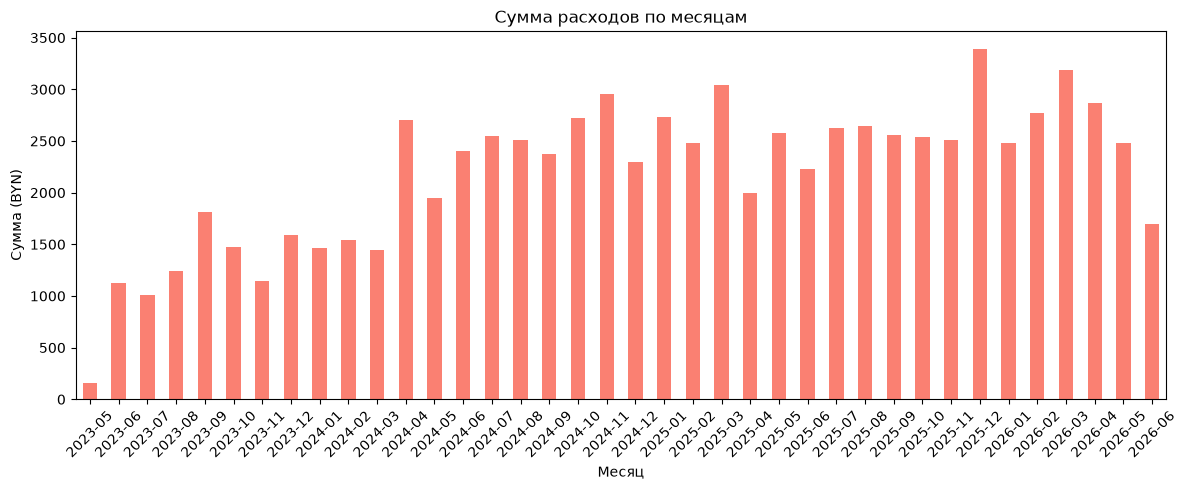

In [6]:
# Сначала добавляем месяц ко всему df
df['month'] = df['operation_date'].dt.to_period('M')

# Теперь заново создаём expenses (уже с колонкой month)
expenses = df[df['is_expense']]

# Расходы по месяцам
monthly_expenses = expenses.groupby('month')['amount'].sum()

print("Расходы по месяцам:")
print(monthly_expenses)

# График
plt.figure(figsize=(12, 5))
monthly_expenses.plot(kind='bar', color='salmon')
plt.title('Сумма расходов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Сумма (BYN)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Словарь соответствий (будем постепенно дополнять)
category_map = {
    'UNIVERSAM': 'Продукты',
    'SHOP SOSEDI': 'Продукты',
    'SHOP "SOSEDI"': 'Продукты',
    'SHOP "SANTA-270" BAPB': 'Продукты',
    'SHOP "EVROOPT"': 'Продукты',
    'SHOP "EUROOPT PRIME"': 'Продукты',
    'MAGAZIN EUROOPT PRIME': 'Продукты',
    'SHOP "MILA"': 'Продукты',
    'SHOP MILA': 'Продукты',
    
    'BUFET': 'Кафе и рестораны',
    'BUFET STOLOVOY N 6': 'Кафе и рестораны',
    'MINI-KAFE PIZZA LISITSTSA': 'Кафе и рестораны',
    'RBO "BURGER KING"': 'Кафе и рестораны',
    
    'TRANSPORT PAYBYCARD.BY': 'Транспорт',
    'YANDEX GO': 'Транспорт',
    
    'WWW.WILDBERRIES.BY': 'Онлайн-магазины',
    'I.-SHOP "WILDBERRIES.BY"': 'Онлайн-магазины',
    
    'INTERNET-BANKING BSB': 'Банковские операции',
    'ON-LINE POPOLNENIE ERIP BSB': 'Пополнения',
}

# Создаём колонку Category
df['category'] = df['place_clean'].map(category_map).fillna('Прочее')

print(df['category'].value_counts())

category
Прочее                 2691
Продукты               1071
Кафе и рестораны        348
Транспорт               203
Пополнения              181
Онлайн-магазины          47
Банковские операции      30
Name: count, dtype: int64


In [8]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # Продукты
    if any(word in place for word in ['SOSEDI', 'SANTA', 'EVROOPT', 'EUROOPT', 'UNIVERSAM', 'GIPPO', 'GREEN', 'MILA', 'GALAMART', 'PROSTORE', 'ALMI']):
        return 'Продукты'
    
    # Кафе и рестораны
    if any(word in place for word in ['KAFE', 'CAFÉ', 'RESTORAN', 'БУФЕТ', 'BUFET', 'STOLOV', 'PIZZA', 'BURGER', 'KFC', 'SUSHI', 'SHAVERMA', 'DONER', 'KEBAB']):
        return 'Кафе и рестораны'
    
    # Транспорт
    if any(word in place for word in ['TRANSPORT', 'YANDEX', 'TAXI', 'АЗС', 'AZS', 'МАЗС']):
        return 'Транспорт'
    
    # Онлайн-магазины
    if any(word in place for word in ['WILDBERRIES', 'OZON', 'JOOM', 'ALIEXPRESS']):
        return 'Онлайн-магазины'
    
    # Аптеки
    if any(word in place for word in ['APTEKA', 'АПТЕКА', 'PHARM']):
        return 'Аптеки'
    
    # Связь
    if any(word in place for word in ['COSMOS', 'TELECOM', 'МТС', 'A1', 'LIFE']):
        return 'Связь'
    
    # Банковские операции
    if any(word in place for word in ['INTERNET-BANKING', 'ERIP', 'PEREVOD', 'P2P', 'COMPAY']):
        return 'Банковские операции'
    
    return 'Прочее'

# Применяем функцию
df['category'] = df['place'].apply(get_category)

print(df['category'].value_counts())

category
Продукты               1672
Прочее                 1320
Кафе и рестораны        912
Банковские операции     257
Транспорт               234
Онлайн-магазины          91
Аптеки                   65
Связь                    20
Name: count, dtype: int64


In [9]:
# Смотрим, что осталось в категории «Прочее»
prochee = df[df['category'] == 'Прочее']

print("Количество записей в Прочее:", len(prochee))
print("\nТоп-40 мест, которые всё ещё в Прочее:")
print(prochee['place'].value_counts().head(40))

Количество записей в Прочее: 1320

Топ-40 мест, которые всё ещё в Прочее:
place
ZAO Superprod                 51
I.-SHOP"WWW.PASS.RW.BY"       29
SHOP IZYUM                    28
ZAKUS. "B.PEREMENA"BAPB       24
TO "OOO VKUSFRI I K"          20
SHOP "KHIT STANDART"          20
TORG.MESTO N3                 19
SHOP N9869                    16
SHOP "NASHA LAVKA N2" BAP     16
TM N3                         14
HELLO                         14
FIRM.SHOP "KARAVAY" BAPB      13
SHOP "KOPEECHKA"              13
SHOP "KHIT EKSPRESS"          13
TP "KOLOBOK" BAPB             13
LOTUS BUBBLE TEA              13
Vesyolyj ponchik              12
SHOP "MAYAK"                  12
KOP                           12
SHOP N9863                    11
SHOP TRI TSENY                11
KOFEYNYA BAPB                 11
PAV. N66 BAPB                 10
TORGOVY LOTOK "KOFE SAUND"    10
SHOP N9863 FIX PRICE          10
TORGOVY OBEKT BAPB             9
SHOP "TRI TSENY"               9
Mag.Karandash                

In [10]:
# Приводим place к верхнему регистру и убираем все кавычки
df['place'] = (
    df['place']
    .astype(str)                    # на всякий случай делаем строкой
    .str.upper()                    # всё в верхний регистр
    .str.replace('"', '', regex=False)  # убираем обычные кавычки
    .str.replace('«', '', regex=False)  # убираем ёлочки (если есть)
    .str.replace('»', '', regex=False)
    .str.strip()                    # убираем лишние пробелы по краям
)

# Проверяем результат
print(df['place'].value_counts().head(20))

place
SHOP SOSEDI                    548
UNIVERSAM                      423
BUFET                          196
ON-LINE POPOLNENIE ERIP BSB    181
TRANSPORT PAYBYCARD.BY         162
SHOP SANTA-270 BAPB            158
BUFET STOLOVOY N 6             112
SHOP EVROOPT                    88
RBO BURGER KING                 86
SHOP EUROOPT PRIME              80
SHOP MILA                       77
ZAO SUPERPROD                   51
STOLOVAYA N 6                   47
WWW.WILDBERRIES.BY              47
SHOP GALAMART BAPB              44
YANDEX GO                       41
MINI-KAFE PIZZA LISITSTSA       40
I.-SHOP WILDBERRIES.BY          37
COMPAY BIB EPAYMENTS OPLA       35
INTERNET-BANKING BSB            30
Name: count, dtype: int64


In [11]:
prochee = df[df['category'] == 'Прочее']

print("Количество записей в Прочее:", len(prochee))
print("\nТоп-40 мест, которые всё ещё в Прочее:")
print(prochee['place'].value_counts().head(40))

Количество записей в Прочее: 1320

Топ-40 мест, которые всё ещё в Прочее:
place
ZAO SUPERPROD               51
I.-SHOPWWW.PASS.RW.BY       29
SHOP IZYUM                  28
ZAKUS. B.PEREMENABAPB       24
TO OOO VKUSFRI I K          20
SHOP KHIT STANDART          20
SHOP TRI TSENY              20
TORG.MESTO N3               19
SHOP KOPEECHKA              17
SHOP N9869                  16
SHOP NASHA LAVKA N2 BAP     16
SHOP MAYAK                  15
TM N3                       14
HELLO                       14
FIRM.SHOP KARAVAY BAPB      13
SHOP KHIT EKSPRESS          13
TP KOLOBOK BAPB             13
LOTUS BUBBLE TEA            13
VESYOLYJ PONCHIK            12
KOP                         12
SHOP N9863                  11
KOFEYNYA BAPB               11
PAV. N66 BAPB               10
TORGOVY LOTOK KOFE SAUND    10
SHOP N9863 FIX PRICE        10
TORGOVY OBEKT BAPB           9
MAG.KARANDASH                9
CRISPY                       9
SHOP N11 VITEB.PRODUKTY      9
MAGAZIN N4           

In [12]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # 1. Продукты
    if any(word in place for word in ['SOSEDI', 'SANTA', 'EVROOPT', 'EUROOPT', 'UNIVERSAM', 'GIPPO', 'GREEN', 'MILA', 'GALAMART', 'PROSTORE', 'ALMI', 'IZYUM', 'KOPEECHKA', 'KARAVAY', 'NASHA LAVKA', 'MAYAK', 'TRI TSENY', 'FIX PRICE', 'SUPERPROD', 'PRODUKTY']):
        return 'Продукты'
    
    # 2. Кафе и рестораны
    if any(word in place for word in ['KAFE', 'CAFÉ', 'RESTORAN', 'БУФЕТ', 'BUFET', 'STOLOV', 'PIZZA', 'BURGER', 'KFC', 'SUSHI', 'SHAVERMA', 'DONER', 'KEBAB', 'PEREMENA', 'VKUSFRI', 'BUBBLE TEA', 'COFFEE', 'KOFE', 'CRISPY', 'PONCHIK']):
        return 'Кафе и рестораны'
    
    # 3. Транспорт
    if any(word in place for word in ['TRANSPORT', 'YANDEX', 'TAXI', 'АЗС', 'AZS', 'МАЗС', 'PASS.RW', 'HELLO']):
        return 'Транспорт'
    
    # 4. Онлайн-магазины
    if any(word in place for word in ['WILDBERRIES', 'OZON', 'JOOM', 'ALIEXPRESS']):
        return 'Онлайн-магазины'
    
    # 5. Аптеки
    if any(word in place for word in ['APTEKA', 'АПТЕКА', 'PHARM',]):
        return 'Аптеки'
    
    # 6. Связь
    if any(word in place for word in ['COSMOS', 'TELECOM']):
        return 'Связь'
    
    # 7. Развлечения
    if any(word in place for word in ['KINO', 'SKYLINE', 'MUZEY']):
        return 'Развлечения'
    
    # 8. Банковские операции
    if any(word in place for word in ['INTERNET-BANKING', 'ERIP', 'PEREVOD', 'P2P', 'COMPAY']):
        return 'Банковские операции'
    #9. Дом и быт
    if any (word in place for word in ['OSTROV CHIST' , 'MILA','TRI TSENY ']):
        return 'Дом и быт'
    # Если ничего не подошло
    return 'Прочее'

In [13]:
#ЗАКОНЧИЛ НА ДОБАВЛЕНИИ КАТЕГОРИЙ В ВЫПИСКЕ

In [14]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # 1. Продукты
    if any(word in place for word in ['KOLOBOK','MESTO N3','SOSEDI','KHIT', 'SANTA', 'EVROOPT', 'EUROOPT', 'UNIVERSAM', 'GIPPO', 'GREEN', 'MILA', 'GALAMART', 'PROSTORE', 'ALMI', 'IZYUM', 'KOPEECHKA', 'KARAVAY', 'NASHA LAVKA', 'MAYAK', 'TRI TSENY', 'FIX PRICE', 'SUPERPROD', 'PRODUKTY']):
        return 'Продукты'
    # 2. Кафе и рестораны
    if any(word in place for word in ['LISITSTSA', 'KAFE', 'CAFÉ', 'RESTORAN', 'БУФЕТ', 'BUFET', 'STOLOV', 'PIZZA', 'BURGER', 'KFC', 'SUSHI', 'SHAVERMA', 'DONER', 'KEBAB', 'PEREMENA', 'VKUSFRI', 'BUBBLE TEA', 'COFFEE', 'KOFE', 'CRISPY', 'PONCHIK']):
        return 'Кафе и рестораны'
    
    # 3. Транспорт
    if any(word in place for word in ['TRANSPORT', 'YANDEX', 'TAXI', 'АЗС', 'AZS', 'МАЗС', 'PASS.RW', 'HELLO']):
        return 'Транспорт'
    
    # 4. Онлайн-магазины
    if any(word in place for word in ['WILDBERRIES', 'OZON', 'JOOM', 'ALIEXPRESS']):
        return 'Онлайн-магазины'
    
    # 5. Аптеки
    if any(word in place for word in ['APTEKA', 'АПТЕКА', 'PHARM']):
        return 'Аптеки'
    
    # 6. Связь
    if any(word in place for word in ['COSMOS', 'TELECOM']):
        return 'Связь'
    
    # 7. Развлечения
    if any(word in place for word in ['KINO', 'SKYLINE', 'MUZEY']):
        return 'Развлечения'
    
    # 8. Банковские операции
    if any(word in place for word in ['INTERNET-BANKING', 'ERIP', 'PEREVOD', 'P2P', 'COMPAY']):
        return 'Банковские операции'
    
    # 9. Дом и быт
    if any(word in place for word in ['OSTROV CHIST', 'MILA', 'TRI TSENY']):
        return 'Дом и быт'
    
    return 'Прочее'

# Применяем
df['category'] = df['place'].apply(get_category)
print(df['category'].value_counts())

category
Продукты               1939
Кафе и рестораны       1053
Прочее                  830
Транспорт               283
Банковские операции     257
Онлайн-магазины          91
Аптеки                   65
Развлечения              24
Связь                    20
Дом и быт                 9
Name: count, dtype: int64


In [15]:
prochee = df[df['category'] == 'Прочее']

print("Количество записей в Прочее:", len(prochee))
print("\nТоп-40 мест, которые всё ещё в Прочее:")
print(prochee['place'].value_counts().head(40))

Количество записей в Прочее: 830

Топ-40 мест, которые всё ещё в Прочее:
place
SHOP N9869                   16
TM N3                        14
KOP                          12
SHOP N9863                   11
PAV. N66 BAPB                10
TORGOVY OBEKT BAPB            9
MAG.KARANDASH                 9
MAGAZIN N4                    9
ZAKUSOCHNAYA EKSPRES          9
SHOP BAPB                     8
SHOP N 53 UP DORORS           8
SHOP N4 FABRIKA ZDOROVYA      8
SHOP N 154                    7
PAVILYON EXPRESS              7
PON-PUSHKA MOLODEZHK          7
IP MONAHOVA E.M.              6
ZH/D STANTS.BOGUSHEVSK        6
SYAO FAN DGHUO                6
FORMOSA                       6
SHAURMA V PIVE                6
MELEK - VOSTOCHNAYA           6
TO OOO VKUSARI I K            6
SHOP GROSHYK                  6
PERSON TO PERSON MP BSB       6
GIPERMARKET LEONARDO          6
TO N2 BAPB                    6
SAKAVIK                       6
DOST.GOTOVOY EDY ART FOOD     5
SHOP N9998               

In [16]:
prochee = df[df['category'] == 'Прочее']

print("Всего записей в категории «Прочее»:", len(prochee))
print("\nТоп-50 мест, которые остались в «Прочее»:\n")
print(prochee['place'].value_counts().head(50))

Всего записей в категории «Прочее»: 830

Топ-50 мест, которые остались в «Прочее»:

place
SHOP N9869                    16
TM N3                         14
KOP                           12
SHOP N9863                    11
PAV. N66 BAPB                 10
TORGOVY OBEKT BAPB             9
MAG.KARANDASH                  9
MAGAZIN N4                     9
ZAKUSOCHNAYA EKSPRES           9
SHOP BAPB                      8
SHOP N 53 UP DORORS            8
SHOP N4 FABRIKA ZDOROVYA       8
SHOP N 154                     7
PAVILYON EXPRESS               7
PON-PUSHKA MOLODEZHK           7
IP MONAHOVA E.M.               6
ZH/D STANTS.BOGUSHEVSK         6
SYAO FAN DGHUO                 6
FORMOSA                        6
SHAURMA V PIVE                 6
MELEK - VOSTOCHNAYA            6
TO OOO VKUSARI I K             6
SHOP GROSHYK                   6
PERSON TO PERSON MP BSB        6
GIPERMARKET LEONARDO           6
TO N2 BAPB                     6
SAKAVIK                        6
DOST.GOTOVOY EDY AR

In [17]:
prochee = df[df['category'] == 'Прочее']

print("Всего операций в «Прочее»:", len(prochee))
print("Общая сумма трат в «Прочее»:", prochee['amount'].sum().round(2), "BYN\n")

print("Топ-30 мест в категории «Прочее» по сумме расходов:\n")

top_by_sum = (
    prochee.groupby('place')['amount']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Сумма', 'count': 'Кол-во операций'})
    .sort_values('Сумма', ascending=False)
    .head(30)
    .round(2)
)

print(top_by_sum)

Всего операций в «Прочее»: 830
Общая сумма трат в «Прочее»: 18135.17 BYN

Топ-30 мест в категории «Прочее» по сумме расходов:

                             Сумма  Кол-во операций
place                                              
PERSON TO PERSON MP BSB    4228.00                6
SHOP PYATY ELEMENT          395.20                4
IR WWW.24AFISHA.BY BSB      275.00                3
DOST.GOTOVOY EDY ART FOOD   266.35                5
SHOP N9869                  219.41               16
IZYSKANNAYA KUHN            189.50                1
DZHINSOMANIYA SHOP          180.00                1
SHOP N9863                  175.65               11
REDSTAR SHOP                165.00                1
21VEK.BY                    152.68                3
I.-SHOP WWW.CROCUS24.BY     150.00                3
TM N3                       145.90               14
SYAO FAN DGHUO              145.00                6
PAB 12                      144.50                2
GIPERMARKET LEONARDO        143.11       

In [18]:
# Смотрим все операции PERSON TO PERSON
p2p = df[df['place'].str.contains('PERSON TO PERSON', case=False, na=False)]

print("Количество операций:", len(p2p))
print("Общая сумма:", p2p['amount'].sum().round(2), "BYN\n")

print("Подробности по операциям:\n")
print(
    p2p[['operation_date', 'description', 'place', 'amount', 'balance']]
    .sort_values('operation_date')
    .to_string()
)

Количество операций: 6
Общая сумма: 4228.0 BYN

Подробности по операциям:

     operation_date                                 description                    place  amount  balance
1205     2024-04-25  Оплата товаров и услуг в устройствах Банка  PERSON TO PERSON MP BSB   872.0     0.00
1226     2024-04-29  Оплата товаров и услуг в устройствах Банка  PERSON TO PERSON MP BSB    70.0  1070.27
1321     2024-05-27  Оплата товаров и услуг в устройствах Банка  PERSON TO PERSON MP BSB   847.0     0.00
1476     2024-06-25  Оплата товаров и услуг в устройствах Банка  PERSON TO PERSON MP BSB   807.0  1338.97
1625     2024-07-26  Оплата товаров и услуг в устройствах Банка  PERSON TO PERSON MP BSB   813.0  1242.41
1758     2024-08-26  Оплата товаров и услуг в устройствах Банка  PERSON TO PERSON MP BSB   819.0  1287.35


In [19]:
# Применяем функцию (если ещё не применял)
df['category'] = df['place'].apply(get_category)

# Смотрим распределение по количеству операций
print("Распределение по количеству операций:")
print(df['category'].value_counts())
print()

# Смотрим распределение по сумме денег
print("Распределение по сумме расходов:")
print(
    df[df['is_expense']]
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
    .round(2)
)

Распределение по количеству операций:
category
Продукты               1939
Кафе и рестораны       1053
Прочее                  830
Транспорт               283
Банковские операции     257
Онлайн-магазины          91
Аптеки                   65
Развлечения              24
Связь                    20
Дом и быт                 9
Name: count, dtype: int64

Распределение по сумме расходов:
category
Продукты               28464.71
Банковские операции    20101.01
Прочее                 16286.17
Кафе и рестораны       11547.38
Онлайн-магазины         3175.44
Транспорт               1745.67
Аптеки                   805.90
Развлечения              517.40
Связь                    441.47
Дом и быт                196.17
Name: amount, dtype: float64


In [20]:
prochee = df[df['category'] == 'Прочее']

print("Топ-25 мест в «Прочее» по сумме расходов:\n")

print(
    prochee.groupby('place')['amount']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Сумма', 'count': 'Операций'})
    .sort_values('Сумма', ascending=False)
    .head(25)
    .round(2)
)

Топ-25 мест в «Прочее» по сумме расходов:

                             Сумма  Операций
place                                       
PERSON TO PERSON MP BSB    4228.00         6
SHOP PYATY ELEMENT          395.20         4
IR WWW.24AFISHA.BY BSB      275.00         3
DOST.GOTOVOY EDY ART FOOD   266.35         5
SHOP N9869                  219.41        16
IZYSKANNAYA KUHN            189.50         1
DZHINSOMANIYA SHOP          180.00         1
SHOP N9863                  175.65        11
REDSTAR SHOP                165.00         1
21VEK.BY                    152.68         3
I.-SHOP WWW.CROCUS24.BY     150.00         3
TM N3                       145.90        14
SYAO FAN DGHUO              145.00         6
PAB 12                      144.50         2
GIPERMARKET LEONARDO        143.11         6
SEN KHANOY                  141.00         5
SHAURMA V PIVE              140.00         6
TO OOO PRINOSIM RADOST      134.48         3
AZIATSKOE BISTRO            132.00         2
TC IMPULS BS

In [21]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # 1. Аренда
    if any(word in place for word in ['PERSON TO PERSON', 'INTERNET-BANKING']):
        return 'Аренда'
    
    # 2. Продукты
    if any(word in place for word in [
        'SOSEDI', 'SANTA', 'EVROOPT', 'EUROOPT', 'UNIVERSAM', 'GIPPO', 'GREEN', 
        'MILA', 'GALAMART', 'PROSTORE', 'ALMI', 'IZYUM', 'KOPEECHKA', 'KARAVAY', 
        'NASHA LAVKA', 'MAYAK', 'TRI TSENY', 'FIX PRICE', 'SUPERPROD', 'PRODUKTY',
        'N9869', 'IZYSKANNAYA KUHN', 'TM N3'
    ]):
        return 'Продукты'
    
    # 3. Кафе и рестораны + доставка
    if any(word in place for word in [
        'KAFE', 'CAFÉ', 'RESTORAN', 'БУФЕТ', 'BUFET', 'STOLOV', 'PIZZA', 'BURGER', 
        'KFC', 'SUSHI', 'SHAVERMA', 'DONER', 'KEBAB', 'PEREMENA', 'VKUSFRI', 
        'BUBBLE TEA', 'COFFEE', 'KOFE', 'CRISPY', 'PONCHIK', 'SYAO FAN', 'PAB 12',
        'SEN KHANOY', 'SHAURMA', 'AZIATSKOE BISTRO', 'TOKINY', 'ART FOOD', 'DOST.GOTOVOY'
    ]):
        return 'Кафе и рестораны'
    
    # 4. Техника для дома
    if any(word in place for word in ['PYATY ELEMENT', '5 ELEMENT', '21VEK', 'DNS ELEKTRONIKA']):
        return 'Техника'
    
    # 5. Одежда
    if any(word in place for word in ['DZHINSOMANIYA']):
        return 'Одежда'
    
    # 6. Аптеки
    if any(word in place for word in ['APTEKA', 'АПТЕКА', 'PHARM', 'FABRIKA ZDOROVYA']):
        return 'Аптеки'
    
    # 7. Транспорт
    if any(word in place for word in ['TRANSPORT', 'YANDEX', 'TAXI', 'АЗС', 'AZS', 'МАЗС', 'PASS.RW', 'HELLO']):
        return 'Транспорт'
    
    # 8. Онлайн-магазины / Маркетплейсы
    if any(word in place for word in ['WILDBERRIES', 'OZON', 'JOOM', 'ALIEXPRESS', 'PRINOSIM RADOST']):
        return 'Онлайн-магазины'
    
    # 9. Развлечения
    if any(word in place for word in ['KINO', 'SKYLINE', 'MUZEY', '24AFISHA']):
        return 'Развлечения'
    
    # 10. Снятие наличных
    if any(word in place for word in ['ATM']):
        return 'Снятие наличных'
    
    # 11. Хобби
    if any(word in place for word in ['LEONARDO']):
        return 'Хобби'
    
    # 12. Подарки / Цветы
    if any(word in place for word in ['CROCUS24']):
        return 'Подарки'
    
    # 13. Связь
    if any(word in place for word in ['COSMOS', 'TELECOM']):
        return 'Связь'
    
    # 14. Дом и быт
    if any(word in place for word in ['OSTROV CHIST']):
        return 'Дом и быт'
    
    # 15. Банковские операции
    if any(word in place for word in ['ERIP', 'PEREVOD', 'P2P', 'COMPAY']):
        return 'Банковские операции'
    
    return 'Прочее'

In [22]:
df['category'] = df['place'].apply(get_category)

print("Новое распределение по сумме расходов:")
print(
    df[df['is_expense']]
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
    .round(2)
)

Новое распределение по сумме расходов:
category
Продукты               28438.74
Аренда                 23863.95
Кафе и рестораны       12383.35
Прочее                  9188.35
Онлайн-магазины         3309.92
Транспорт               1745.67
Аптеки                   907.14
Развлечения              792.40
Техника                  763.99
Банковские операции      465.06
Связь                    441.47
Снятие наличных          312.00
Дом и быт                196.17
Одежда                   180.00
Подарки                  150.00
Хобби                    143.11
Name: amount, dtype: float64


In [23]:
prochee = df[df['category'] == 'Прочее']

print("Топ-25 мест в «Прочее» по сумме расходов:\n")

print(
    prochee.groupby('place')['amount']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Сумма', 'count': 'Операций'})
    .sort_values('Сумма', ascending=False)
    .head(25)
    .round(2)
)

Топ-25 мест в «Прочее» по сумме расходов:

                           Сумма  Операций
place                                     
PITSTSA LISITSTSA         250.73         8
TORG.MESTO N3             185.40        19
SHOP N9863                175.65        11
REDSTAR SHOP              165.00         1
SHOP KHIT EKSPRESS        134.71        13
SHOP KHIT STANDART        133.46        20
TP KOLOBOK BAPB            98.04        13
OOO PEINT-MARKET           96.00         2
FORMOSA                    95.00         6
NOODLES                    95.00         1
INT.-RES.MOB.PRIL.APPIKA   90.00         1
IP KUPRIYANOVICH T.B       90.00         1
SHOP 41 TVOYO BPSB         89.98         1
KEAWAY.UHG.BY/BALKON       88.80         2
KHINKALNYA RESTAURANT      84.90         2
PON-PUSHKA MOLODEZHK       84.00         7
OOO CHIKOBEL               84.00         1
TAPIOCA                    80.00         4
RESTAURANT TIFLIS          78.80         1
KOP                        77.80        12
PT UP MINGA

In [24]:
# Показываем топ-30 мест из Прочее с суммой
top_prochee = (
    df[df['category'] == 'Прочее']
    .groupby('place')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .round(2)
)

print("Топ-30 мест в «Прочее»:\n")
for i, (place, amount) in enumerate(top_prochee.items(), 1):
    print(f"{i:2}. {place:<40} {amount:>8.2f} BYN")

Топ-30 мест в «Прочее»:

 1. PITSTSA LISITSTSA                          250.73 BYN
 2. TORG.MESTO N3                              185.40 BYN
 3. SHOP N9863                                 175.65 BYN
 4. REDSTAR SHOP                               165.00 BYN
 5. SHOP KHIT EKSPRESS                         134.71 BYN
 6. SHOP KHIT STANDART                         133.46 BYN
 7. TP KOLOBOK BAPB                             98.04 BYN
 8. OOO PEINT-MARKET                            96.00 BYN
 9. FORMOSA                                     95.00 BYN
10. NOODLES                                     95.00 BYN
11. INT.-RES.MOB.PRIL.APPIKA                    90.00 BYN
12. IP KUPRIYANOVICH T.B                        90.00 BYN
13. SHOP 41 TVOYO BPSB                          89.98 BYN
14. KEAWAY.UHG.BY/BALKON                        88.80 BYN
15. KHINKALNYA RESTAURANT                       84.90 BYN
16. PON-PUSHKA MOLODEZHK                        84.00 BYN
17. OOO CHIKOBEL                               

In [25]:
import json

with open("exact_map.json", "r", encoding="utf-8") as f:
    exact_map = json.load(f)

print(f"Загружено {len(exact_map)} мест")
print(exact_map)

Загружено 60 мест
{'PITSTSA LISITSTSA': 'Кафе и рестораны', 'TORG.MESTO N3': 'Продукты', 'SHOP N9863': 'Продукты', 'REDSTAR SHOP': 'Одежда', 'SHOP KHIT EKSPRESS': 'Продукты', 'SHOP KHIT STANDART': 'Продукты', 'TP KOLOBOK BAPB': 'Продукты', 'FORMOSA': 'Кафе и рестораны', 'NOODLES': 'Кафе и рестораны', 'KEAWAY.UHG.BY/BALKON': 'Кафе и рестораны', 'KHINKALNYA RESTAURANT': 'Кафе и рестораны', 'OOO CHIKOBEL': 'Кафе и рестораны', 'PON-PUSHKA MOLODEZHK': 'Кафе и рестораны', 'TAPIOCA': 'Кафе и рестораны', 'RESTAURANT TIFLIS': 'Кафе и рестораны', 'PT UP MINGAZ': 'Дом и быт', 'SHOP GROSHYK': 'Продукты', 'RBO SALATEIRA': 'Кафе и рестораны', 'KARIBARA': 'Кафе и рестораны', 'ZH/D STANTS.BOGUSHEVSK': 'Продукты', 'PT TEKHNIKA USPEKHA': 'Техника', 'SHOP N9998': 'Продукты', 'OOO EDA S UMOM': 'Кафе и рестораны', 'I.-SHOP WWW.NAVERANDE.BY': 'Подарки', 'SPICHKI': 'Кафе и рестораны', 'CHAYNAYA LAVKA LOTUS': 'Кафе и рестораны', 'ZAKUSOCHNAYA EKSPRES': 'Кафе и рестораны', 'SHOP N 154': 'Продукты', 'NEO CUSHI'

In [26]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # ===== Точные совпадения из файла =====
    if place in exact_map:
        return exact_map[place]
    
    # ===== Дальше твои старые правила =====
    if any(word in place for word in ['PERSON TO PERSON', 'INTERNET-BANKING']):
        return 'Аренда'
    
    # ... все остальные if any(...) оставляй как были
    
    return 'Прочее'

In [27]:
df['category'] = df['place'].apply(get_category)

print("Новое распределение по сумме:")
print(
    df[df['is_expense']]
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
    .round(2)
)

Новое распределение по сумме:
category
Прочее              55407.05
Аренда              23863.95
Кафе и рестораны     2372.25
Продукты             1086.84
Одежда                200.47
Дом и быт             119.36
Развлечения           102.00
Техника                67.40
Подарки                62.00
Name: amount, dtype: float64


In [28]:
# 1. Проверяем, загрузился ли exact_map
print("Количество записей в exact_map:", len(exact_map))
print("Примеры из exact_map:")
print(list(exact_map.items())[:10])

Количество записей в exact_map: 60
Примеры из exact_map:
[('PITSTSA LISITSTSA', 'Кафе и рестораны'), ('TORG.MESTO N3', 'Продукты'), ('SHOP N9863', 'Продукты'), ('REDSTAR SHOP', 'Одежда'), ('SHOP KHIT EKSPRESS', 'Продукты'), ('SHOP KHIT STANDART', 'Продукты'), ('TP KOLOBOK BAPB', 'Продукты'), ('FORMOSA', 'Кафе и рестораны'), ('NOODLES', 'Кафе и рестораны'), ('KEAWAY.UHG.BY/BALKON', 'Кафе и рестораны')]


In [29]:
# 2. Смотрим, как выглядят place в данных
print("Примеры place в данных:")
print(df['place'].dropna().unique()[:15])

Примеры place в данных:
<StringArray>
[  'DOST.GOTOVOY EDY ART FOOD',         'SHOP SANTA-270 BAPB',
                    'KAFE BSB', 'ON-LINE POPOLNENIE ERIP BSB',
    'D-R OSTROV CHIST.I VKUSA',   'MINI-KAFE PIZZA LISITSTSA',
                 'OOO MARMELY',          'RBO KARTOFFEL BAPB',
             'KIOSK N290 BAPB',             'RBO BURGER KING',
     'MAST. PO IZGOT.KLYUCHEY',           'PON-PUSHKA NEMIGA',
                    'TO GIPPO',           'I.-SHOP 5 ELEMENT',
                     'PEREVOD']
Length: 15, dtype: str


In [30]:
# 3. Проверяем, срабатывает ли exact_map
test_places = list(exact_map.keys())[:5]

for place in test_places:
    result = get_category(place)
    print(f"{place} → {result}")

PITSTSA LISITSTSA → Кафе и рестораны
TORG.MESTO N3 → Продукты
SHOP N9863 → Продукты
REDSTAR SHOP → Одежда
SHOP KHIT EKSPRESS → Продукты


In [31]:
# 4. Смотрим, что сейчас лежит в «Прочее» (топ по сумме)
print(
    df[df['category'] == 'Прочее']
    .groupby('place')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .round(2)
)

place
ON-LINE POPOLNENIE ERIP BSB    82752.84
SHOP SOSEDI                     6583.98
UNIVERSAM                       4429.33
SHOP SANTA-270 BAPB             3211.23
SHOP EUROOPT PRIME              2733.99
WWW.WILDBERRIES.BY              1892.04
SHOP MILA                       1752.54
SHOP EVROOPT                    1282.50
I.-SHOP WILDBERRIES.BY          1088.89
SHOP GALAMART BAPB              1066.88
MINI-KAFE PIZZA LISITSTSA       1065.45
BUFET                           1042.63
MAGAZIN EUROOPT PRIME            959.63
RBO BURGER KING                  704.38
ZAO SUPERPROD                    668.11
Name: amount, dtype: float64


In [32]:
def get_category(place):
    if pd.isna(place):
        return 'Прочее'
    
    place = str(place).upper()
    
    # ===== 1. Сначала точные совпадения из JSON =====
    if place in exact_map:
        return exact_map[place]
    
    # ===== 2. Потом правила по ключевым словам =====
    
    # Аренда
    if any(word in place for word in ['PERSON TO PERSON', 'INTERNET-BANKING']):
        return 'Аренда'
    
    # Продукты
    if any(word in place for word in [
        'SOSEDI', 'SANTA', 'EVROOPT', 'EUROOPT', 'UNIVERSAM', 'GIPPO', 'GREEN', 
        'MILA', 'GALAMART', 'PROSTORE', 'ALMI', 'IZYUM', 'KOPEECHKA', 'KARAVAY', 
        'NASHA LAVKA', 'MAYAK', 'TRI TSENY', 'FIX PRICE', 'SUPERPROD', 'PRODUKTY',
        'N9869', 'IZYSKANNAYA KUHN', 'TM N3'
    ]):
        return 'Продукты'
    
    # Кафе и рестораны
    if any(word in place for word in [
        'KAFE', 'CAFÉ', 'RESTORAN', 'БУФЕТ', 'BUFET', 'STOLOV', 'PIZZA', 'BURGER', 
        'KFC', 'SUSHI', 'SHAVERMA', 'DONER', 'KEBAB', 'PEREMENA', 'VKUSFRI', 
        'BUBBLE TEA', 'COFFEE', 'KOFE', 'CRISPY', 'PONCHIK', 'SYAO FAN', 'PAB 12',
        'SEN KHANOY', 'SHAURMA', 'AZIATSKOE BISTRO', 'TOKINY', 'ART FOOD', 'DOST.GOTOVOY',
        'PITSTSA', 'LISITSTSA'
    ]):
        return 'Кафе и рестораны'
    
    # Техника
    if any(word in place for word in ['PYATY ELEMENT', '5 ELEMENT', '21VEK', 'DNS ELEKTRONIKA']):
        return 'Техника'
    
    # Одежда
    if any(word in place for word in ['DZHINSOMANIYA', 'REDSTAR']):
        return 'Одежда'
    
    # Аптеки
    if any(word in place for word in ['APTEKA', 'АПТЕКА', 'PHARM', 'FABRIKA ZDOROVYA']):
        return 'Аптеки'
    
    # Транспорт
    if any(word in place for word in ['TRANSPORT', 'YANDEX', 'TAXI', 'АЗС', 'AZS', 'МАЗС', 'PASS.RW', 'HELLO']):
        return 'Транспорт'
    
    # Онлайн-магазины
    if any(word in place for word in ['WILDBERRIES', 'OZON', 'JOOM', 'ALIEXPRESS', 'PRINOSIM RADOST']):
        return 'Онлайн-магазины'
    
    # Развлечения
    if any(word in place for word in ['KINO', 'SKYLINE', 'MUZEY', '24AFISHA']):
        return 'Развлечения'
    
    # Снятие наличных
    if any(word in place for word in ['ATM']):
        return 'Снятие наличных'
    
    # Хобби
    if any(word in place for word in ['LEONARDO']):
        return 'Хобби'
    
    # Подарки
    if any(word in place for word in ['CROCUS24']):
        return 'Подарки'
    
    # Связь
    if any(word in place for word in ['COSMOS', 'TELECOM']):
        return 'Связь'
    
    # Дом и быт
    if any(word in place for word in ['OSTROV CHIST']):
        return 'Дом и быт'
    
    # Банковские операции
    if any(word in place for word in ['ERIP', 'PEREVOD', 'P2P', 'COMPAY']):
        return 'Банковские операции'
    
    return 'Прочее'

In [33]:
df['category'] = df['place'].apply(get_category)

In [34]:
# 4. Смотрим, что сейчас лежит в «Прочее» (топ по сумме)
print(
    df[df['category'] == 'Прочее']
    .groupby('place')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .round(2)
)

place
OOO PEINT-MARKET            96.00
IP KUPRIYANOVICH T.B        90.00
INT.-RES.MOB.PRIL.APPIKA    90.00
SHOP 41 TVOYO BPSB          89.98
KOP                         77.80
PRIEMNYY PUNKT 18           68.00
VYEZD.TORG-LYA N6 BAPB      65.99
3 ETAZH CAFE                65.70
CRMBVB HO140 EXPOBEL        62.00
STATES                      61.00
IP REPITSKY A.V             60.00
IP MONAHOVA E.M.            58.80
PAVILYON EXPRESS            57.43
MAGAZIN N4                  56.51
HOQQA                       54.00
Name: amount, dtype: float64


In [35]:
df['category'] = df['place'].apply(get_category)

print("Новое распределение по сумме:")
print(
    df[df['is_expense']]
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
    .round(2)
)

Новое распределение по сумме:
category
Продукты               29525.58
Аренда                 23863.95
Кафе и рестораны       14755.60
Прочее                  5178.03
Онлайн-магазины         3309.92
Транспорт               1745.67
Аптеки                   907.14
Развлечения              894.40
Техника                  831.39
Банковские операции      465.06
Связь                    441.47
Одежда                   380.47
Дом и быт                315.53
Снятие наличных          312.00
Подарки                  212.00
Хобби                    143.11
Name: amount, dtype: float64


In [36]:
print("Топ-20 мест в категории «Прочее» по сумме:\n")
print('Количество операций в прочих ',len(place))
print(
    df[df['category'] == 'Прочее']
    .groupby('place')['amount']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Сумма', 'count': 'Операций'})
    .sort_values('Сумма', ascending=False)
    .head(20)
    .round(2)
)

Топ-20 мест в категории «Прочее» по сумме:

Количество операций в прочих  18
                          Сумма  Операций
place                                    
OOO PEINT-MARKET          96.00         2
IP KUPRIYANOVICH T.B      90.00         1
INT.-RES.MOB.PRIL.APPIKA  90.00         1
SHOP 41 TVOYO BPSB        89.98         1
KOP                       77.80        12
PRIEMNYY PUNKT 18         68.00         1
VYEZD.TORG-LYA N6 BAPB    65.99         1
3 ETAZH CAFE              65.70         2
CRMBVB HO140 EXPOBEL      62.00         2
STATES                    61.00         3
IP REPITSKY A.V           60.00         1
IP MONAHOVA E.M.          58.80         6
PAVILYON EXPRESS          57.43         7
MAGAZIN N4                56.51         9
HOQQA                     54.00         2
MAG.KARANDASH             52.42         9
OOO BELDRINKTORG PAB      52.00         1
SHOP N 18 TVOE BPSB       51.96         2
SPECALFAGRUPP             50.50         4
CLAIR DELICIOUS           50.00         2

In [37]:
df.head()

,operation_date,transaction_date,card_last4,description,place,currency,amount_original,amount,balance,is_expense,is_income,place_clean,month,category
0,2023-05-12,2023-05-12,4995.0,Online открытие текущего счета с последующим в...,NaN,BYN,0.0,0.0,0.0,False,False,NaN,2023-05,Прочее
1,2023-05-29,2023-05-28,4995.0,Оплата товаров и услуг в устройствах других ба...,DOST.GOTOVOY EDY ART FOOD,BYN,34.3,34.3,0.0,True,False,DOST.GOTOVOY EDY ART FOOD,2023-05,Кафе и рестораны
2,2023-05-29,2023-05-28,4995.0,Оплата товаров и услуг в устройствах других ба...,SHOP SANTA-270 BAPB,BYN,26.0,26.0,0.0,True,False,SHOP SANTA-270 BAPB,2023-05,Продукты
3,2023-05-29,2023-05-28,4995.0,Оплата товаров и услуг в устройствах Банка,KAFE BSB,BYN,14.3,14.3,0.0,True,False,KAFE BSB,2023-05,Кафе и рестораны
4,2023-05-29,2023-05-28,8176.0,Пополнение счета Ерип,ON-LINE POPOLNENIE ERIP BSB,BYN,185.0,185.0,110.4,False,True,ON-LINE POPOLNENIE ERIP BSB,2023-05,Банковские операции


In [38]:
df.tail()

,operation_date,transaction_date,card_last4,description,place,currency,amount_original,amount,balance,is_expense,is_income,place_clean,month,category
4566,2026-06-26,2026-06-25,8307.0,Оплата товаров и услуг в устройствах других ба...,SHOP SOSEDI,BYN,6.61,6.61,1478.50,True,False,SHOP SOSEDI,2026-06,Продукты
4567,2026-06-26,2026-06-25,2489.0,Оплата товаров и услуг в устройствах других ба...,SHOP MILA,BYN,25.21,25.21,1453.29,True,False,SHOP MILA,2026-06,Продукты
4568,2026-06-26,2026-06-24,2489.0,Оплата товаров и услуг в устройствах других ба...,OOO FITOBEL APTEKA N18,BYN,24.75,24.75,1428.54,True,False,OOO FITOBEL APTEKA N18,2026-06,Аптеки
4569,2026-06-26,2026-06-24,2489.0,Оплата товаров и услуг в устройствах других ба...,SHOP MAYAK,BYN,1.29,1.29,1427.25,True,False,SHOP MAYAK,2026-06,Продукты
4570,2026-06-26,2026-06-24,2489.0,Оплата товаров и услуг в устройствах других ба...,SHOP SOSEDI,BYN,6.15,6.15,1421.10,True,False,SHOP SOSEDI,2026-06,Продукты


category
Продукты               29525.58
Аренда                 23863.95
Кафе и рестораны       14755.60
Прочее                  5178.03
Онлайн-магазины         3309.92
Транспорт               1745.67
Аптеки                   907.14
Развлечения              894.40
Техника                  831.39
Банковские операции      465.06
Связь                    441.47
Одежда                   380.47
Дом и быт                315.53
Снятие наличных          312.00
Подарки                  212.00
Хобби                    143.11
Name: amount, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_18268\3480377810.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sum.values, y=category_sum.index, palette='viridis')


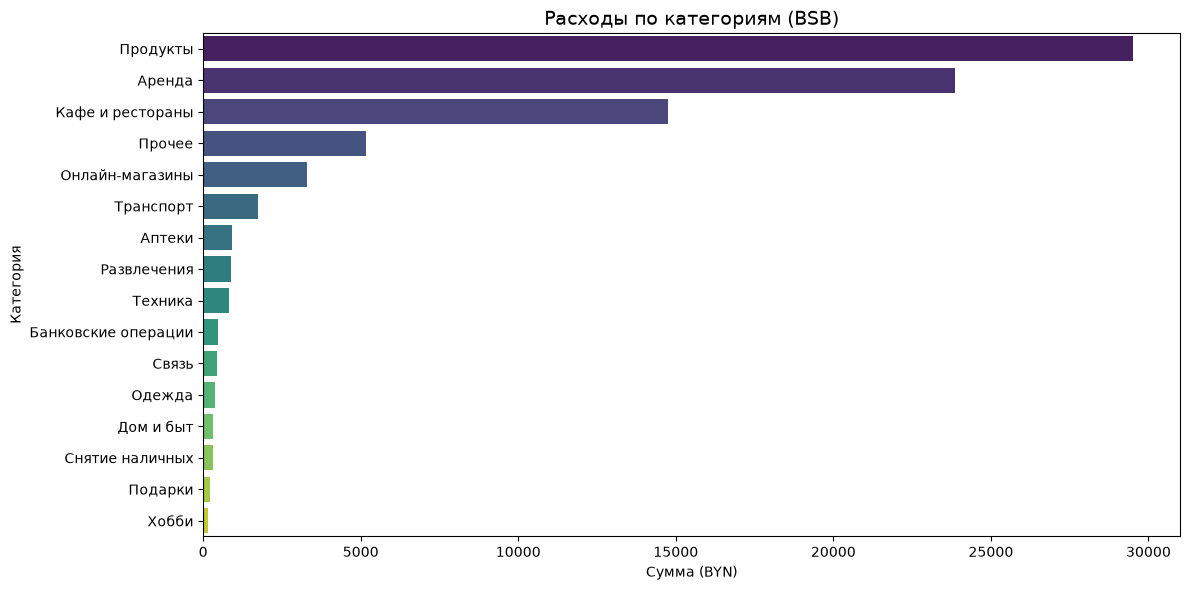

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Считаем сумму по категориям (только расходы)
category_sum = (
    df[df['is_expense']]
    .groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
)

print(category_sum.round(2))

# Строим график
plt.figure(figsize=(12, 6))
sns.barplot(x=category_sum.values, y=category_sum.index, palette='viridis')
plt.title('Расходы по категориям (BSB)', fontsize=14)
plt.xlabel('Сумма (BYN)')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

In [40]:
df['year'] = df['operation_date'].dt.year
df['month'] = df['operation_date'].dt.month

print("Доступные годы:")
print(sorted(df['year'].unique()))

print("\nКоличество операций по годам и месяцам:")
print(df.groupby(['year', 'month']).size().unstack(fill_value=0))

Доступные годы:
[np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]

Количество операций по годам и месяцам:
month   1    2    3    4    5    6    7    8    9    10   11   12
year                                                             
2023     0    0    0    0   11  105   90  121  126  110  101   94
2024    99  107  130  139  128  140  146  137  123  123  115  110
2025   105  105  132  115  137   90  140  135  159  144  130  143
2026   123  138  134  131  129  126    0    0    0    0    0    0


C:\Users\User\AppData\Local\Temp\ipykernel_18268\3353004714.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=may_sum.values, y=may_sum.index, ax=axes[0], palette='Blues_r')
C:\Users\User\AppData\Local\Temp\ipykernel_18268\3353004714.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_sum.values, y=year_sum.index, ax=axes[1], palette='Greens_r')


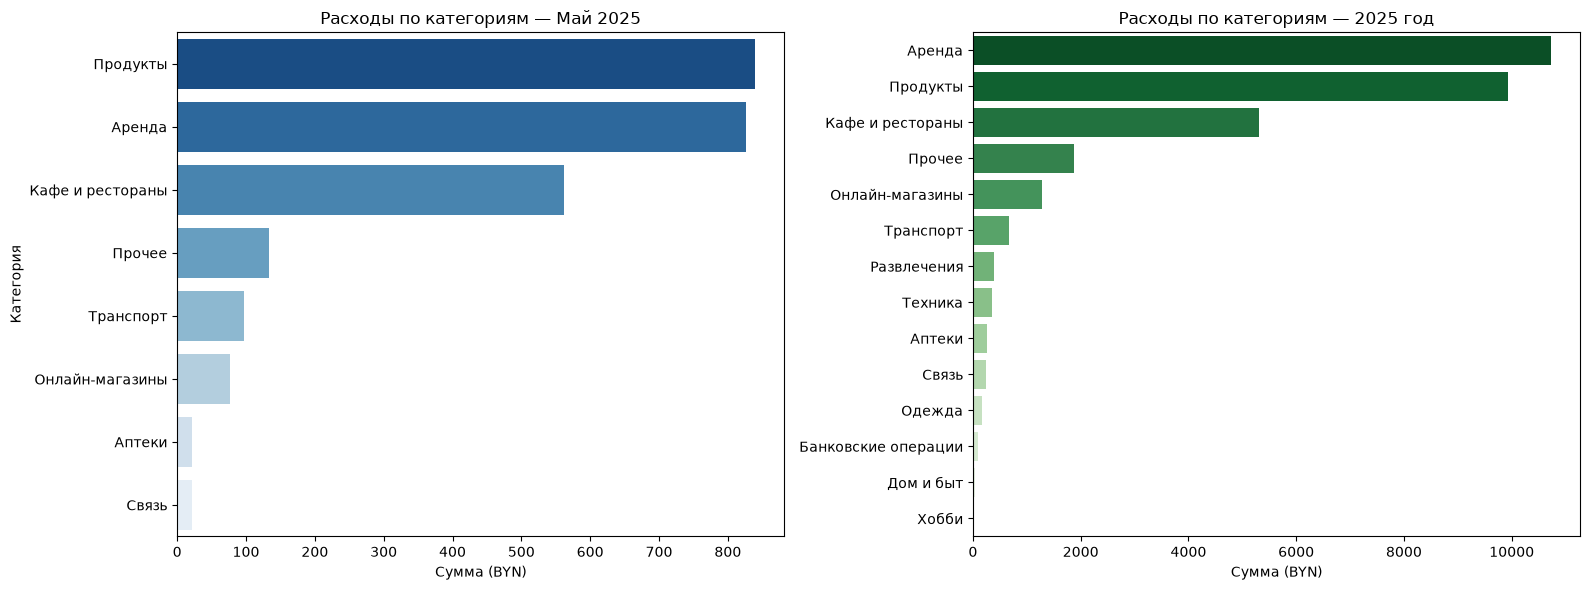

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Фильтруем данные
may_2025 = df[(df['year'] == 2025) & (df['month'] == 5) & (df['is_expense'])]
year_2025 = df[(df['year'] == 2025) & (df['is_expense'])]

# Считаем суммы по категориям
may_sum = may_2025.groupby('category')['amount'].sum().sort_values(ascending=False)
year_sum = year_2025.groupby('category')['amount'].sum().sort_values(ascending=False)

# Два графика рядом
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Левый график — Май 2025
sns.barplot(x=may_sum.values, y=may_sum.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Расходы по категориям — Май 2025')
axes[0].set_xlabel('Сумма (BYN)')
axes[0].set_ylabel('Категория')

# Правый график — Весь 2025 год
sns.barplot(x=year_sum.values, y=year_sum.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Расходы по категориям — 2025 год')
axes[1].set_xlabel('Сумма (BYN)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [42]:
year_2025 = df[(df['year'] == 2025) & (df['is_expense'])]

category_sum = year_2025.groupby('category')['amount'].sum().sort_values(ascending=False)
total = category_sum.sum()

share = (category_sum / total * 100).round(1)

print("Доля категорий в 2025 году (%):")
print(share)

Доля категорий в 2025 году (%):
category
Аренда                 34.3
Продукты               31.7
Кафе и рестораны       16.9
Прочее                  6.0
Онлайн-магазины         4.1
Транспорт               2.1
Развлечения             1.2
Техника                 1.1
Аптеки                  0.8
Связь                   0.8
Одежда                  0.5
Банковские операции     0.3
Дом и быт               0.1
Хобби                   0.0
Name: amount, dtype: float64


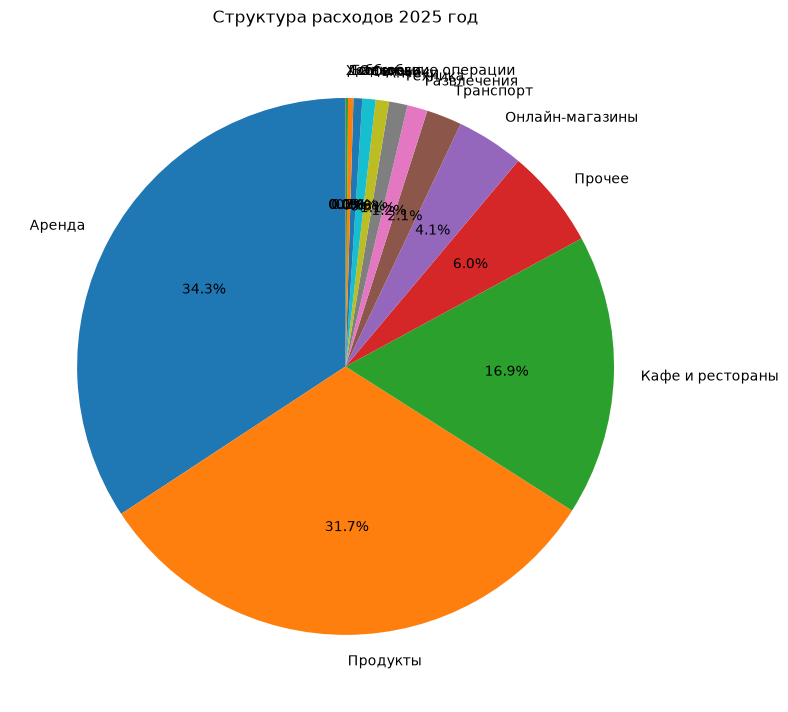

In [43]:
plt.figure(figsize=(8, 8))
plt.pie(
    category_sum,
    labels=category_sum.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Структура расходов 2025 год')
plt.tight_layout()
plt.show()


In [44]:
year_2025 = df[(df['year'] == 2025) & (df['is_expense'])]

summary = (
    year_2025
    .groupby('category')
    .agg(
        Сумма=('amount', 'sum'),
        Операций=('amount', 'count'),
        Средний_чек=('amount', 'mean')
    )
    .sort_values('Сумма', ascending=False)
    .round(2)
)

print(summary)

                        Сумма  Операций  Средний_чек
category                                            
Аренда               10730.93        15       715.40
Продукты              9938.44       678        14.66
Кафе и рестораны      5305.88       373        14.22
Прочее                1869.14       172        10.87
Онлайн-магазины       1274.83        29        43.96
Транспорт              665.90       116         5.74
Развлечения            382.00        15        25.47
Техника                348.30         2       174.15
Аптеки                 253.38        20        12.67
Связь                  247.53        12        20.63
Одежда                 165.00         1       165.00
Банковские операции    100.50        13         7.73
Дом и быт               42.05         2        21.02
Хобби                    4.82         1         4.82


In [45]:
summary_all = (
    df[df['is_expense']]
    .groupby('category')
    .agg(
        Сумма=('amount', 'sum'),
        Операций=('amount', 'count'),
        Средний_чек=('amount', 'mean')
    )
    .sort_values('Сумма', ascending=False)
    .round(2)
)

print(summary_all)

                        Сумма  Операций  Средний_чек
category                                            
Продукты             29525.58      2005        14.73
Аренда               23863.95        36       662.89
Кафе и рестораны     14755.60      1180        12.50
Прочее                5178.03       492        10.52
Онлайн-магазины       3309.92        92        35.98
Транспорт             1745.67       281         6.21
Аптеки                 907.14        73        12.43
Развлечения            894.40        30        29.81
Техника                831.39        11        75.58
Банковские операции    465.06        45        10.33
Связь                  441.47        20        22.07
Одежда                 380.47         3       126.82
Дом и быт              315.53        13        24.27
Снятие наличных        312.00         7        44.57
Подарки                212.00         4        53.00
Хобби                  143.11         6        23.85


In [46]:
transport = df[df['category'] == 'Транспорт']

print("Количество операций:", len(transport))
print("\nПримеры транзакций:")
print(
    transport[['operation_date', 'place', 'amount', 'description']]
    .sort_values('operation_date', ascending=False)
    .head(20)
    .to_string()
)

Количество операций: 283

Примеры транзакций:
     operation_date                   place  amount                                         description
4513     2026-06-17  TRANSPORT PAYBYCARD.BY    1.15  Оплата товаров и услуг в устройствах других банков
4512     2026-06-17  TRANSPORT PAYBYCARD.BY    1.15  Оплата товаров и услуг в устройствах других банков
4511     2026-06-17  TRANSPORT PAYBYCARD.BY    1.15  Оплата товаров и услуг в устройствах других банков
4510     2026-06-17  TRANSPORT PAYBYCARD.BY    1.15  Оплата товаров и услуг в устройствах других банков
4482     2026-06-11  TRANSPORT PAYBYCARD.BY    1.15  Оплата товаров и услуг в устройствах других банков
4431     2026-05-26  MOBIL. PRIL. YANDEX GO   11.10  Оплата товаров и услуг в устройствах других банков
4425     2026-05-25  TRANSPORT PAYBYCARD.BY    1.15  Оплата товаров и услуг в устройствах других банков
4389     2026-05-18  MOBIL. PRIL. YANDEX GO   15.90  Оплата товаров и услуг в устройствах других банков
4390     2026-05-1

In [47]:
pivot = pd.pivot_table(
    data=df[df['is_expense']],
    values='amount',
    index='category',
    columns='year',
    aggfunc='sum',
    fill_value=0
).round(2)

print(pivot)

year                    2023     2024      2025     2026
category                                                
Аптеки                186.80   293.82    253.38   173.14
Аренда                  0.00  7771.00  10730.93  5362.02
Банковские операции    37.56   110.00    100.50   217.00
Дом и быт             155.04    35.89     42.05    82.55
Кафе и рестораны     2624.04  5126.08   5305.88  1699.60
Одежда                  0.00   215.47    165.00     0.00
Онлайн-магазины       467.90   845.66   1274.83   721.53
Подарки                75.00   137.00      0.00     0.00
Продукты             4781.20  9136.69   9938.44  5669.25
Прочее                822.32  1717.19   1869.14   769.38
Развлечения            95.00   271.90    382.00   145.50
Связь                   0.00    51.27    247.53   142.67
Снятие наличных        60.00   252.00      0.00     0.00
Техника               208.81   111.90    348.30   162.38
Транспорт              36.90   740.79    665.90   302.08
Хобби                   0.00   

In [48]:
pivot_mean = pd.pivot_table(
    data=df[df['is_expense']],
    values='amount',
    index='category',
    columns='year',
    aggfunc='mean',
    fill_value=0
).round(2)

print(pivot_mean)

year                  2023    2024    2025    2026
category                                          
Аптеки               12.45   12.24   12.67   12.37
Аренда                0.00  647.58  715.40  595.78
Банковские операции  18.78   55.00    7.73    7.75
Дом и быт            25.84   17.94   21.02   27.52
Кафе и рестораны     12.15   11.00   14.22   13.60
Одежда                0.00  107.74  165.00    0.00
Онлайн-магазины      42.54   26.43   43.96   36.08
Подарки              37.50   68.50    0.00    0.00
Продукты             14.85   14.93   14.66   14.43
Прочее                8.57   11.30   10.87   10.69
Развлечения          31.67   38.84   25.47   29.10
Связь                 0.00   25.64   20.63   23.78
Снятие наличных      20.00   63.00    0.00    0.00
Техника              52.20   55.95  174.15   54.13
Транспорт             1.37    8.32    5.74    6.16
Хобби                 0.00   25.50    4.82   36.27


In [49]:
pivot_multi = pd.pivot_table(
    data=df[df['is_expense']],
    values='amount',
    index='category',
    columns='year',
    aggfunc=['sum', 'count'],
    fill_value=0
).round(2)

print(pivot_multi)

                         sum                             count               
year                    2023     2024      2025     2026  2023 2024 2025 2026
category                                                                     
Аптеки                186.80   293.82    253.38   173.14    15   24   20   14
Аренда                  0.00  7771.00  10730.93  5362.02     0   12   15    9
Банковские операции    37.56   110.00    100.50   217.00     2    2   13   28
Дом и быт             155.04    35.89     42.05    82.55     6    2    2    3
Кафе и рестораны     2624.04  5126.08   5305.88  1699.60   216  466  373  125
Одежда                  0.00   215.47    165.00     0.00     0    2    1    0
Онлайн-магазины       467.90   845.66   1274.83   721.53    11   32   29   20
Подарки                75.00   137.00      0.00     0.00     2    2    0    0
Продукты             4781.20  9136.69   9938.44  5669.25   322  612  678  393
Прочее                822.32  1717.19   1869.14   769.38    96  

In [50]:
# Считаем общую сумму по категориям
pivot_multi['Всего'] = pivot_multi['sum'].sum(axis=1)

# Сортируем
pivot_sorted = pivot_multi.sort_values('Всего', ascending=False)

print(pivot_sorted)

                         sum                             count                 \
year                    2023     2024      2025     2026  2023 2024 2025 2026   
category                                                                        
Продукты             4781.20  9136.69   9938.44  5669.25   322  612  678  393   
Аренда                  0.00  7771.00  10730.93  5362.02     0   12   15    9   
Кафе и рестораны     2624.04  5126.08   5305.88  1699.60   216  466  373  125   
Прочее                822.32  1717.19   1869.14   769.38    96  152  172   72   
Онлайн-магазины       467.90   845.66   1274.83   721.53    11   32   29   20   
Транспорт              36.90   740.79    665.90   302.08    27   89  116   49   
Аптеки                186.80   293.82    253.38   173.14    15   24   20   14   
Развлечения            95.00   271.90    382.00   145.50     3    7   15    5   
Техника               208.81   111.90    348.30   162.38     4    2    2    3   
Банковские операции    37.56